<small>
Introducción a la Ciencia de Datos | Posgrado en Ciencias de la Computación — CICESE  
Tarea 2: Preprocesamiento "Breast Cancer Wisconsin"
</small>

---

# Tarea 2: Procesamiento "Breast Cancer Wisconsin"

## 1. Analisis exploratorio

El analisis comienza con la lectura del archivo `breast-cancer-wisconsin.data`. Este contiene unicamente valores numericos separados por comas, estructurados en **699 filas y 11 columnas** sin encabezados, por lo que requiere documentacion auxiliar para su correcta interpretacion.

Para comprender la estructura de los datos, se reviso el archivo `breast-cancer-wisconsin.names`, el cual documenta el dataset. De este documento se extrae la siguiente informacion:

- **Origen:** University of Wisconsin Hospitals, Madison (Dr. William H. Wolberg).
- **Periodo de recoleccion:** De enero de 1989 a noviembre de 1991. Las muestras se agregaron en 8 grupos:

| Grupo | Instancias | Fecha |
|:-----:|-----------:|-------|
| 1 | 367 | Enero 1989 |
| 2 | 70 | Octubre 1989 |
| 3 | 31 | Febrero 1990 |
| 4 | 17 | Abril 1990 |
| 5 | 48 | Agosto 1990 |
| 6 | 49 | Enero 1991 (actualizado) |
| 7 | 31 | Junio 1991 |
| 8 | 86 | Noviembre 1991 |
| **Total** | **699** | Donado el 15 de julio de 1992 |

- **Atributos:** 10 atributos predictivos mas 1 atributo de clase (11 columnas en total):
  - El primero, `Sample code number`, corresponde unicamente al **identificador** de la muestra y no aporta informacion predictiva.
  - Los 9 atributos siguientes representan **caracteristicas de las celulas**, registradas como valores enteros en una escala del 1 al 10.
  - El ultimo atributo, `Class`, constituye la **variable objetivo**: `2` = benigno, `4` = maligno.

A continuacion, se presenta el DataFrame organizado con sus etiquetas correspondientes para su posterior analisis:

In [5]:
import pandas as pd
from pathlib import Path

data_dir = Path("../../../Datos/Breast Cancer")

path_1 = data_dir / "breast-cancer-wisconsin.data"
path_2 = data_dir / "breast-cancer-wisconsin.names"

columnas = [
    "id", 
    "clump_thickness", 
    "uniformity_cell_size", 
    "uniformity_cell_shape",
    "marginal_adhesion", 
    "single_epithelial_cell_size", 
    "bare_nuclei",
    "bland_chromatin", 
    "normal_nucleoli", 
    "mitoses", 
    "class"
]

df1 = pd.read_csv(path_1 , header=None, names=columnas, na_values="?")

df1


,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2.0,1,1,1,2
695,841769,2,1,1,1,2,1.0,1,1,1,2
696,888820,5,10,10,3,7,3.0,8,10,2,4
697,897471,4,8,6,4,3,4.0,10,6,1,4


---

## 2. Estado inicial del dataset

Dentro del archivo con terminacion `.names`, se indica de manera clara que el dataset contiene valores faltantes marcados con `?`. En consecuencia, se realizara la limpieza de estos valores mediante su reemplazo. En primer lugar, se llevara a cabo una comprobacion para determinar la cantidad exacta de valores faltantes mediante el siguiente proceso:

In [6]:
nulos = df1.isnull().sum()
porcentaje = df1.isnull().mean() *100
pd.DataFrame({
    "nulos": nulos,
    "%": porcentaje.round()
}).query("nulos > 0")

,nulos,%
bare_nuclei,16,2.0


Como se muestra en el codigo anterior podemos ver que hay 16 valores nulos como se menciona en `breast-cancer-wisconsin.names` los cuales representan el 2% de nuestro dataset. 

### 2.1 Descripcion de atributos

Lo siguientes es analizar la escala independiende para cada una de las etiquetas, en el archivo se menciona la siguiente escala para cada etiqueta (Wolberg & Mangasarian, 1990):

   |#|Attribute|Domain|
   |:-:|---|---|
   |1.|Sample code number|id number|
   |2.|Clump Thickness|1 - 10|
   |3.|Uniformity of Cell Size|1 - 10|
   |4.|Uniformity of Cell Shape|1 - 10|
   |5.|Marginal Adhesion|1 - 10|
   |6.|Single Epithelial Cell Size|1 - 10|
   |7.|Bare Nuclei|1 - 10|
   |8.|Bland Chromatin|1 - 10|
   |9.|Normal Nucleoli|1 - 10|
   |10.|Mitoses|1 - 10|
   |11.|Class:|(2 for benign, 4 for malignant)|

A continuacion describire cada una de las etiquetas para mayor claridad en cuanto a la escala asignada:

#### Clump Thickness
Esta etiqueta nos describe la tendencia de las celulas epiteleales a agruparse en capas multiples en lugar de agruparse en una sola capa. Esta etiqueda como las demas esta organizada de 1 a 10, siendo 1 el mejor caso donde el tejido se agrupa de manera plana (celulas beningnas) y al contrario el valor 10 se asigna a aquellas que su agrupacion es desordenada gruesa, indicando un comportamiento de celulas cancerosas (malignas) (Mendoza et al., 2011).

#### Uniformity of Cell Size
Esta nos hablara sobre el grado de variacion de tamaño de las celulas en una muestra. De la misma manera que en la etiqueta anterior, los valores minimos nos describen un comportamiento ideal para la muestra, siendo los valores minimos en este caso para celulas con tamaños uniformes que indican un patron sano. Del lado contrario aquellas con el valor maximo, pertenecen a caractaristicas anormales para las celulas; el comportamiento indicativo de celulas cancerosas es un crecimiento anormal (Robinson et al., 1994).

#### Uniformity of Cell Shape
Otra de las caracteristicas que nos describen el estado de una celula es su forma, aquellas en indices minimos son "sanas", uniformes, fuera de un comportamiento atipico. Generalmente estas celulas tienen una forma circular u ovalada. Su contraparte son quellas con valores maximos en las cuales, las celulas presentan formas irregulares, deformadas y heterogeneas (Elston & Ellis, 1991; Robinson et al., 1994). 

#### Marginal Adhesion
Esta metrica o parametro nos indica la capacidad de las celulas para permanecer unidas entre si en sus bordes o margenes del tejido. Aquellas con valores bajos son celulas que se mantienen firmemente unidas unas a otras. Aquellas con valores altos, nos describen una perdida de adhesion. Estas tienen una tendencia a separarse y despegarse facilemente unas de otras (Mendoza et al., 2011; Robinson et al., 1994).

#### Single Epithelial Cell Size
Mide el grado de agrandamiento del citoplasme y de la estructura completa de una sola celula epitelial en comparacion con el tamaño que deberia de tener. Los valores minimos describen aquellas que conservan sus dimensiones celulares normales y proporcionales. Los valosres maximos muestran un agrandamiento celular significativo, estas celular sufren alteraciones metabolicas y geneticas que a menudo provocan un aumento marcado en su volumen total (Robinson et al., 1994).

#### Bare Nuclei
Esta etiqueta mide la presencia de nucleos celulares desprovistos de su citoplasma rodeando la celula (Virtual Pathology at Leeds, s.f.). Esta etiqueta parece un poco confusa debido a que no es posible tener una celula sin citoplasma, pero entrando mas a detalle esta etiqueta tiene que ver con el proceso de biopsia por aspiracion, como resultado al observar estas celulas se muestran ovaladas y "estiradas"; esta es la principal caracteristica de celulas tumorales, una membrana debil que se rompe al realizar una biopsia.

#### Bland Chromatin
Esta medicion nos habla sobre el estado directo de la cromatina, esta se encarga de empaquetar el material genetico para que se pueda alojar dentro del nucleo (Sehgal & Chaturvedi, 2023). En esta medicion si la cromatina falla al empaquetar el DNA se espera como resultado un nucleo debil o fragil.

#### Normal Nucleoli
Para esta etiqueta se caracterizan la sintesis de ribozomas, que en algunos casos de cancer se un aumento de tamaño nucleolar y su numero eran indicativos de diversos tipos de tumores, tambien la reduccion de sintesis nos habla de una iniciacion tumolar y progreso de cancer (Orsolic et al., 2016). 

#### Mitoses
Esta matrica nos habla sobre la division de las celulas, basicamente al encontrar una division descontrolada, desuniforme o fuera de las caracteristicas tipicas es un fuerte indicativo de un problema division celular que tiene como consecuencia un crecimiento tumoral (Elston & Ellis, 1991).

---

## 3. Tratamiento de valores nulos

### 3.1 Identificacion de columna con valores nulos

Como anteriormente se mostraba, hay 16 valores no nulos dentro de este dataset para analizar. Estos valores representan a penas el 2% del total de mi dataset, por lo cual tendremos la opcion de eliminar las instancias o imputar por mediana. 

In [7]:
nulos_por_columna = df1.isnull().sum()
nulos_por_columna[nulos_por_columna > 0]

bare_nuclei    16
dtype: int64

---

A continuacion se observa el grafico de barras de la **Figura 1: Distribucion de bare nuclei por tipo de diagnostico**. Los pacientes con diagnostico benigno concentran casi todas sus observaciones en el valor minimo (1.0). Por su parte los casos malignos tienen su pico mas alto en el valor maximo (10.0). Esto deja ver de forma muy clara como se separan ambos grupos segun la severidad del atributo.

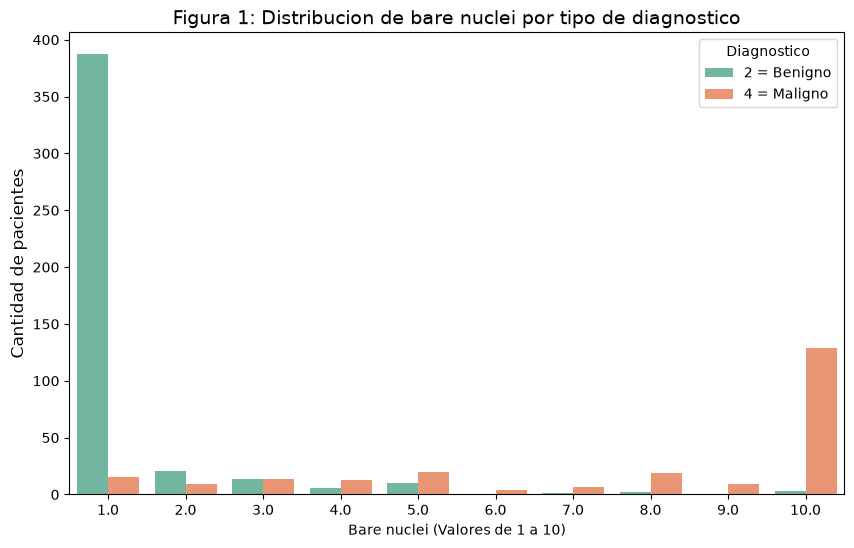

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(data=df1, x="bare_nuclei", hue="class", palette="Set2")

plt.title("Figura 1: Distribucion de bare nuclei por tipo de diagnostico", fontsize=14)
plt.xlabel("Bare nuclei (Valores de 1 a 10)", fontsize=10)
plt.ylabel("Cantidad de pacientes", fontsize=12)
plt.legend(title="Diagnostico", labels=["2 = Benigno", "4 = Maligno"])

plt.savefig("Images/Figura 1 - Distribucion de bare nuclei por tipo de diagnostico", dpi=300, bbox_inches="tight")
plt.show()

---

### 3.2 Imputacion por mediana condicional

Para el tratamiento de los 16 valores faltantes identificados en la columna `bare_nuclei` se descarto el uso de la media global debido a que genera valores decimales fuera del rango discreto original. En su lugar se realizo una imputacion basada en la mediana condicional de cada clase lo que permite conservar valores enteros dentro de la escala de 1 a 10.

In [9]:
mediana_benigno = df1[df1["class"]==2]["bare_nuclei"].median()
mediana_maligno = df1[df1["class"]==4]["bare_nuclei"].median()

print(f"Mediana para clase Benigno (2): {mediana_benigno:.2f}")
print(f"Mediana para clase Maligno (4): {mediana_maligno:.2f}")

df1.loc[(df1["class"]==2) & (df1["bare_nuclei"].isnull()), "bare_nuclei"] = mediana_benigno
df1.loc[(df1["class"]==4) & (df1["bare_nuclei"].isnull()), "bare_nuclei"] = mediana_maligno

Mediana para clase Benigno (2): 1.00
Mediana para clase Maligno (4): 10.00


Como resultado, se determino que la mediana para la clase benigna es 1 y la mediana para la clase maligna es 10. Como se menciono anteriormente, la mediana permitio imputar valores enteros dentro de la columna `bare_nuclei`.

---

In [10]:
print("Nulos restantes en bare_nuclei:", df1["bare_nuclei"].isnull().sum())

Nulos restantes en bare_nuclei: 0


Con el procedimiento anterior se confirmo la ausencia total de valores nulos en el dataset, lo que permite continuar con las siguientes etapas del analisis.

---

En la **Figura 2** podemos observar que al hacer la imputacion de datos con la mediana no se altera la distribucion mostrada en la Figura 1, que incluia los valores nulos. Esto se debe a que estos datos representaban apenas el 2% de las observaciones para la variable `bare_nuclei`.

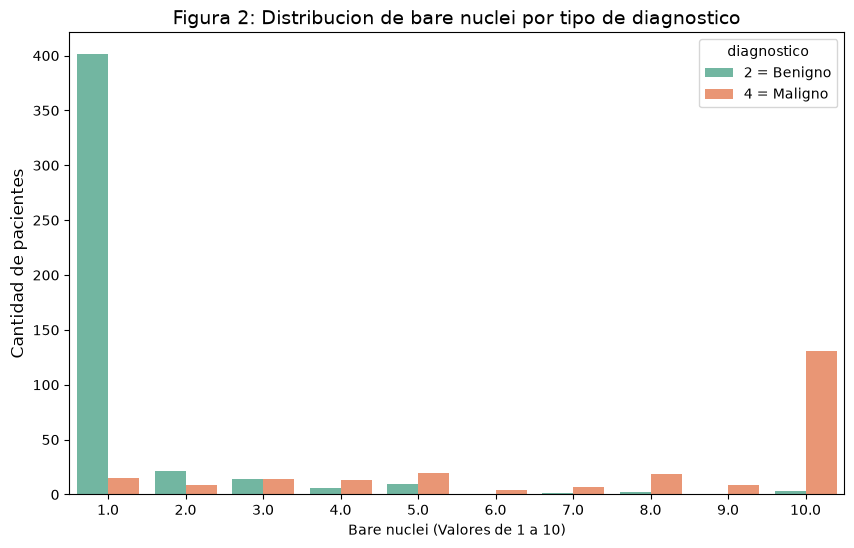

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(data=df1, x="bare_nuclei", hue="class", palette="Set2")

plt.title("Figura 2: Distribucion de bare nuclei por tipo de diagnostico", fontsize=14)
plt.xlabel("Bare nuclei (Valores de 1 a 10)", fontsize=10)
plt.ylabel("Cantidad de pacientes", fontsize=12)
plt.legend(title="diagnostico", labels=["2 = Benigno", "4 = Maligno"])

plt.savefig("Images/Figura 2 - Distribucion de bare nuclei por tipo de diagnostrico")
plt.show()

---

## 4. Distribucion de variables por diagnostico

A continuacion se presentan los graficos de barras correspondientes a las variables del conjunto de datos (**Figuras 3 a 11**), integrando el tratamiento previo de valores faltantes. Esta visualizacion permite comprender la distribucion de las caracteristicas celulares segun la clase de diagnostico (benigno o maligno), facilitando la identificacion de patrones de separabilidad entre ambos grupos.

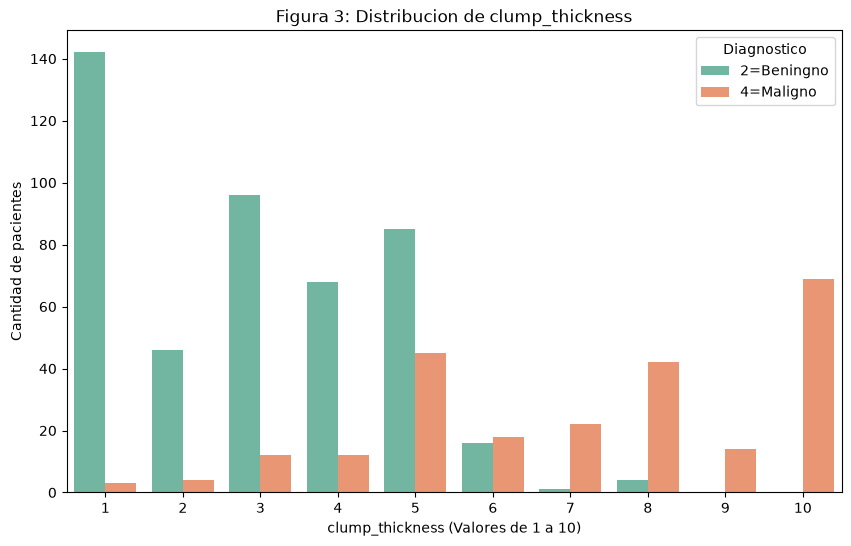

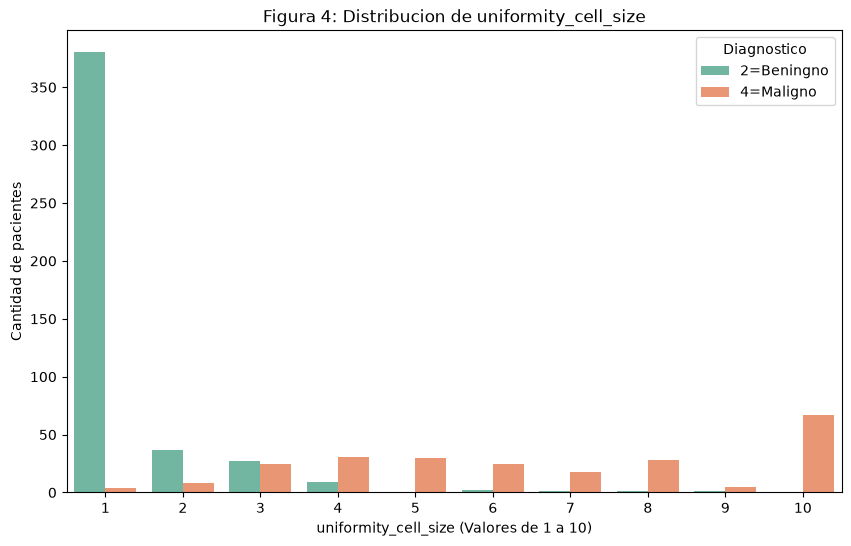

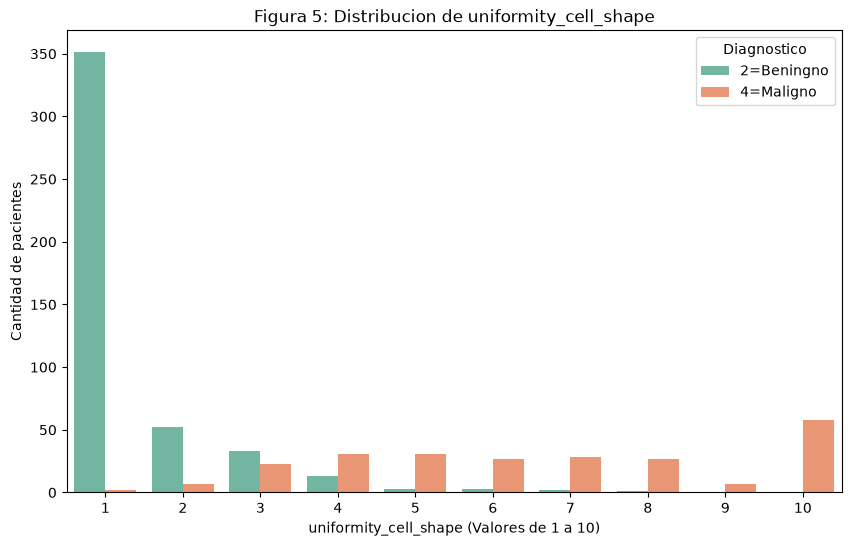

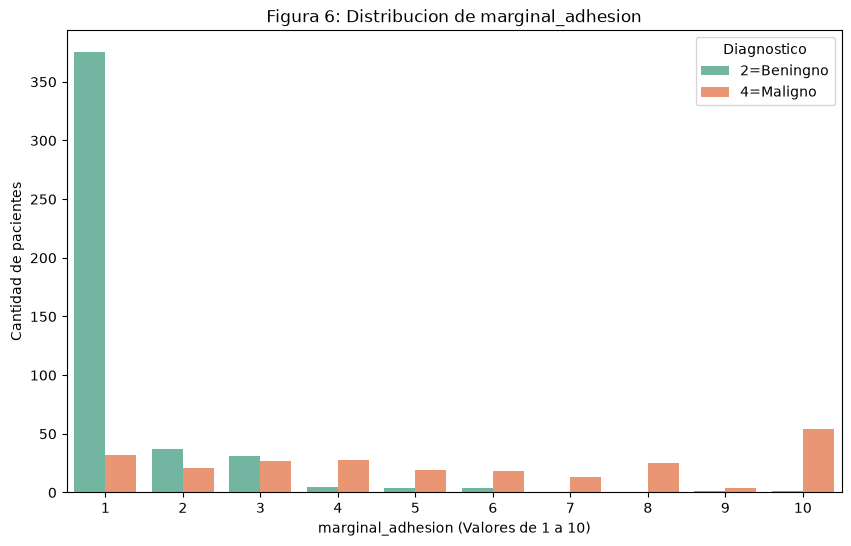

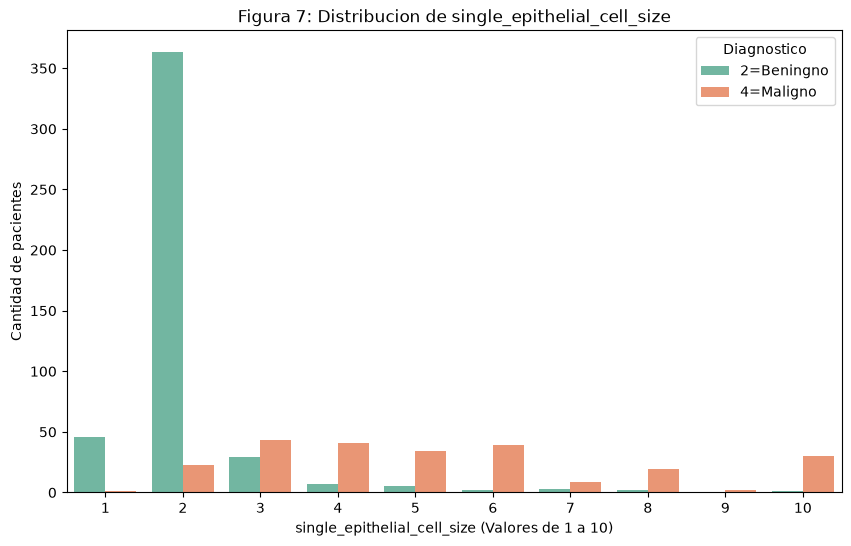

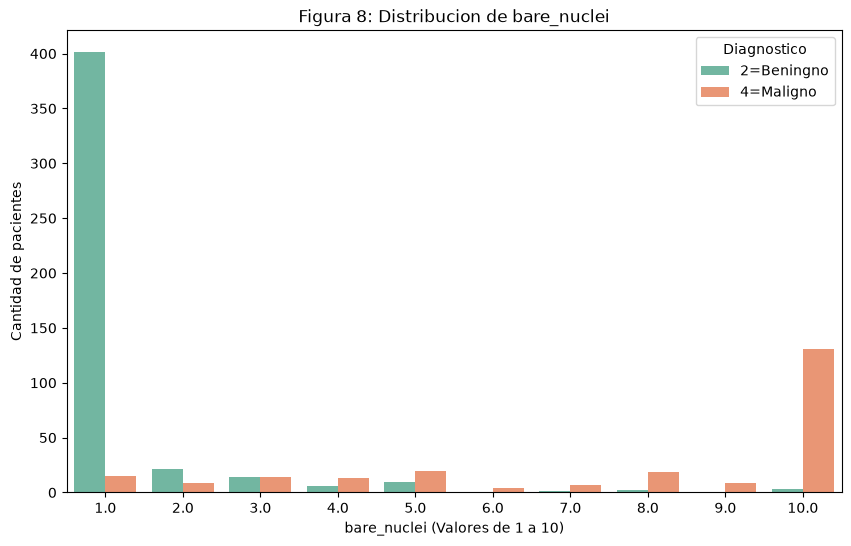

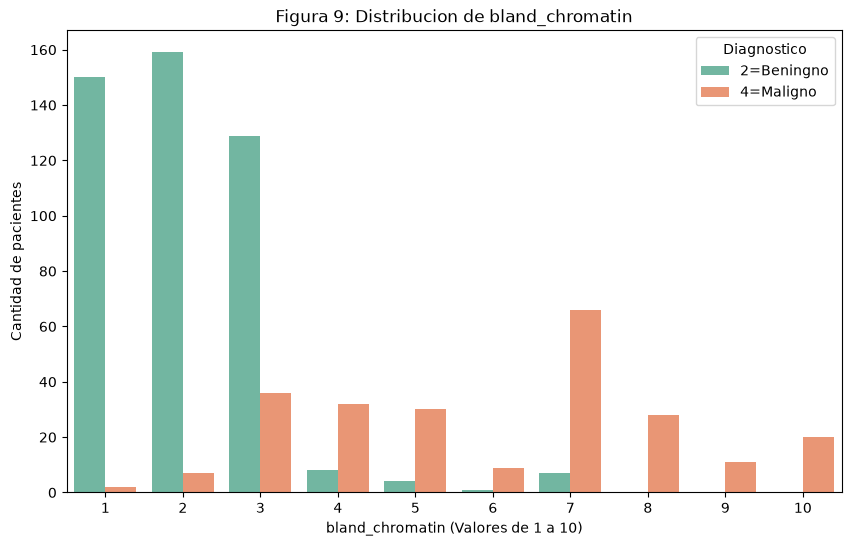

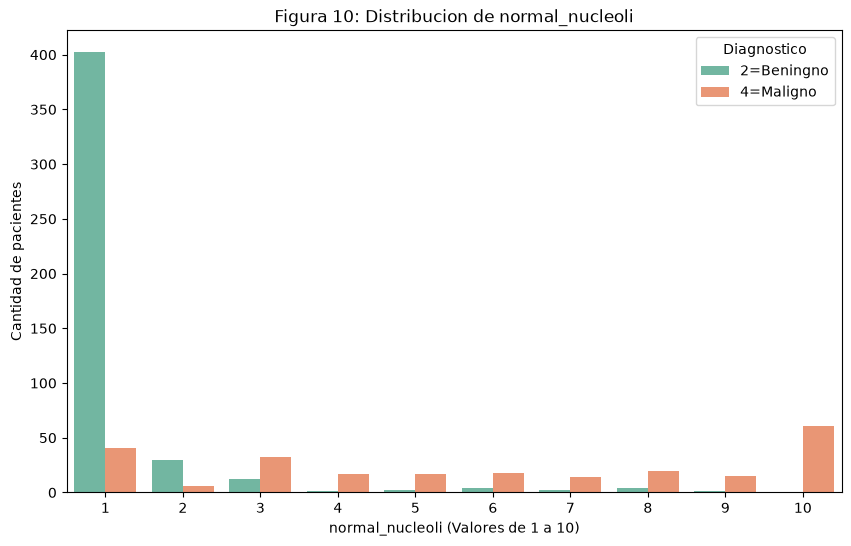

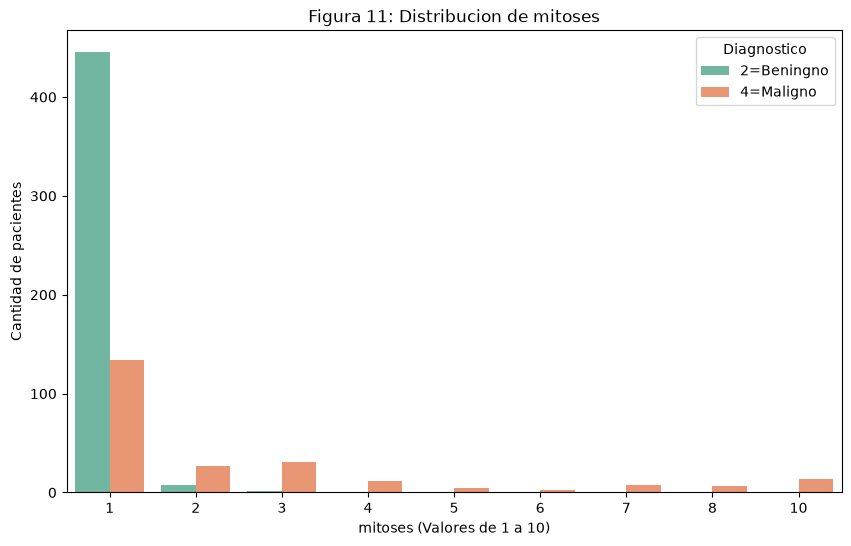

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

columnas_1 = [
    "clump_thickness",
    "uniformity_cell_size",
    "uniformity_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size", 
    "bare_nuclei",
    "bland_chromatin", 
    "normal_nucleoli", 
    "mitoses", 
]

for i, col in enumerate(columnas_1, start=3):
    plt.figure(figsize=(10,6))
    sns.countplot(data=df1, x=col, hue="class", palette="Set2")

    plt.title(f"Figura {i}: Distribucion de {col}")    
    plt.xlabel(col + " (Valores de 1 a 10)")
    plt.ylabel("Cantidad de pacientes")
    plt.legend(title="Diagnostico", labels=["2=Beningno", "4=Maligno"])

    plt.savefig(f"Images/Figura {i} - Distribucion de {col}.png", dpi=300, bbox_inches="tight")
    plt.show()

---

## 5. Deteccion de outliers

Continuando con este analisis me gustaria identificar aquellas etiquetas que nos muestran valores que se podrian ver como outliers, dentro de las graficas de `uniformity_cell_size` (Figura 4), `marginal_adhesion` (Figura 6), `bare_nuclei` (Figura 8) y `normal_nucleoli` (Figura 10) apenas se pueden observar estas caracteristicas que pertenecen a tumores benignos pero se etiquetan similar a valores de tumores malignos. Para ello utilizaremos boxplot para cada una (**Figuras 12 a 15**) y asi observar esta informacion mejor.

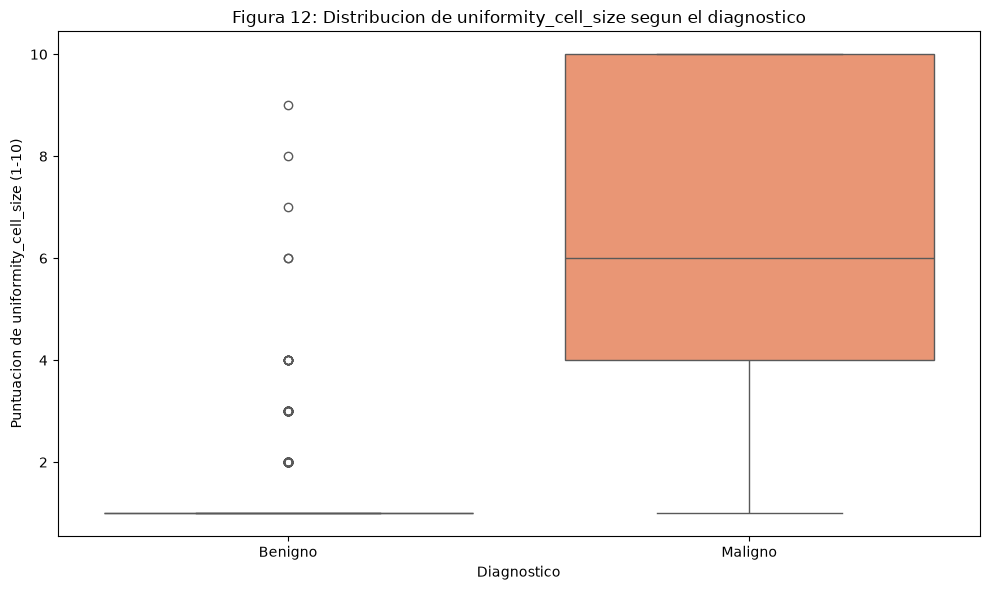

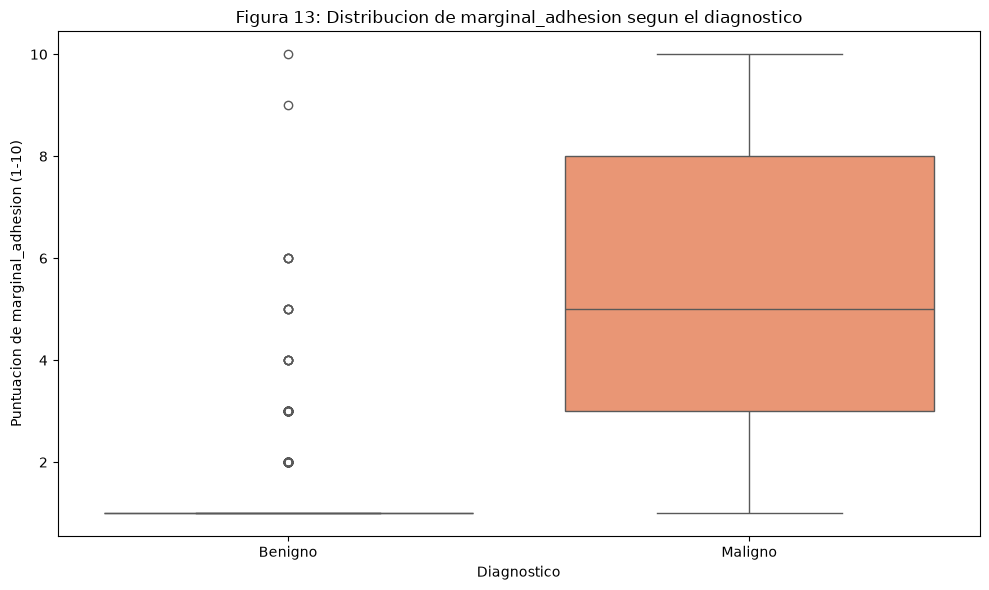

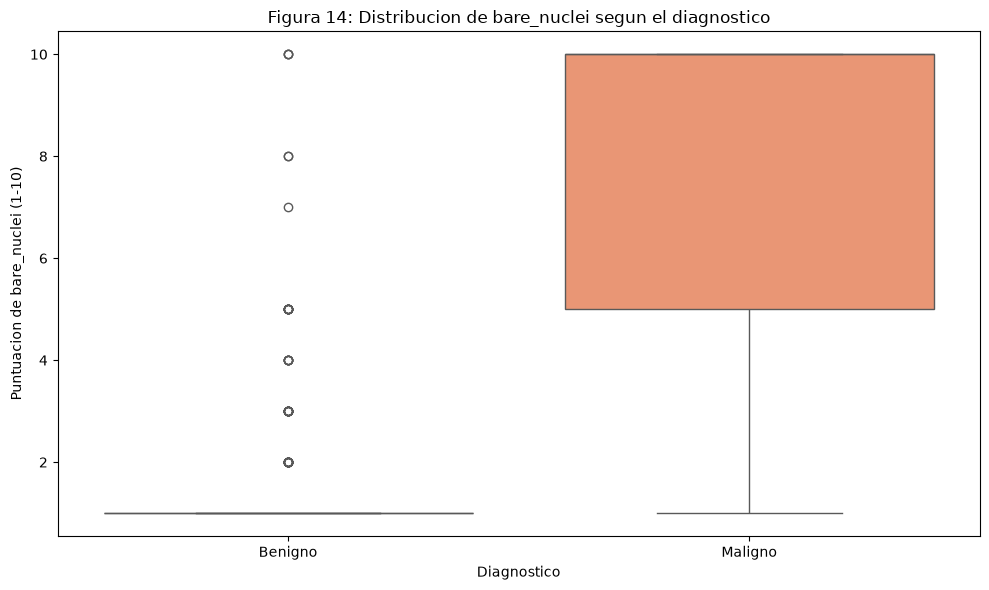

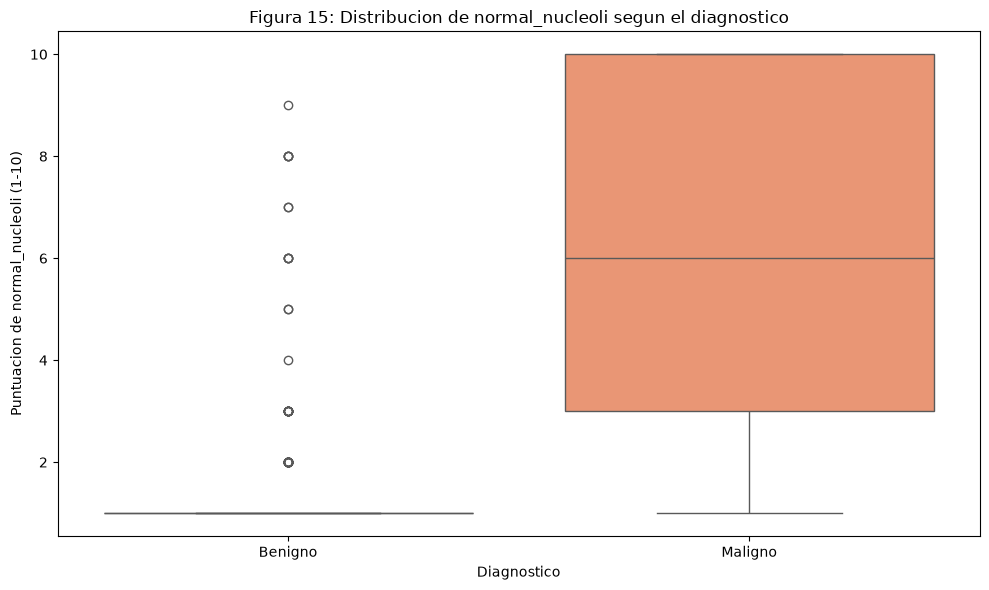

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

df1_plot = df1.copy()
df1_plot["class_label"] = df1_plot["class"].map({2: "Benigno", 4: "Maligno"})

columnas_1 = [
    "uniformity_cell_size",
    "marginal_adhesion", 
    "bare_nuclei",
    "normal_nucleoli", 
]

for i, col in enumerate(columnas_1, start=12):
    plt.figure(figsize=(10,6))
    sns.boxplot(
        data=df1_plot, 
        hue="class_label",
        x="class_label",
        y=col, 
        palette="Set2",
        legend=False
    )

    plt.title(f"Figura {i}: Distribucion de {col} segun el diagnostico", fontsize=12)
    plt.xlabel("Diagnostico")
    plt.ylabel(f"Puntuacion de {col} (1-10)")

    plt.tight_layout()
    plt.savefig(f"Images/Figura {i} - Distribucion de {col} segun el diagnostico.png", dpi=300, bbox_inches="tight")        
    plt.show()

A primera vista podriamos decir que estan incorrectos los graficos de boxplot de las Figuras 12 a 15, pero basicamente nos habla de como esta la distribucion de las etiquetas. Para los casos beningnos tenemos una concentracion de la mayoria de las muestras en 1 o la etiqueta mas baja que esto es normal para tejido sano. Los outliers son pacientes con tumores benignos que presentaron valores atipicos ligeramente mas altos (2-9 en algunos casos). Por el contrario la caja para aquellos tumores malignos presenta una variabilidada mas alta principalmente por la naturaleza de esta patologia, no se concentra solo en un valor.

---

## 6. Matriz de correlacion

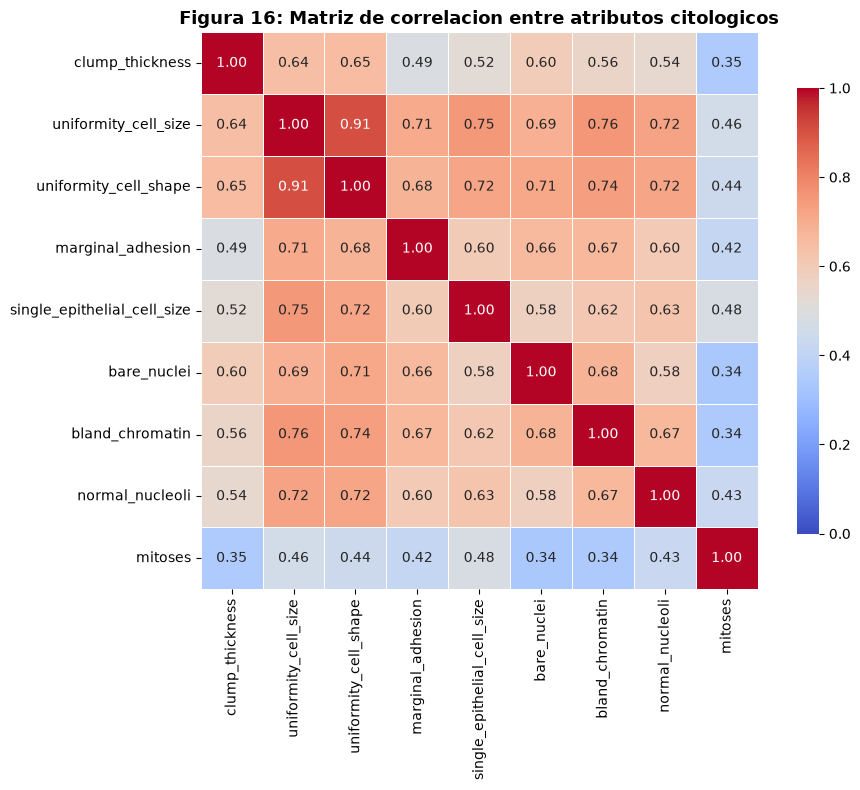

In [22]:
x = df1.drop(
    columns=[
        "id",
        "class"
    ]
)

matriz_correlacion = x.corr()
plt.figure(figsize=(10,8))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmax=1,
    vmin=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title("Figura 16: Matriz de correlacion entre atributos citologicos", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("Images/Figura 16 - Matriz de correlacion entre atributos citologicos.png", dpi=300, bbox_inches="tight")
plt.show()

Se calculo la matriz de correlacion de Pearson (Figura 16) entre las 9 variables citologicas del estudio. Se observa una fuerte correlacion entre `Uniformity_cell_shape` y `uniformity_cell_size` de 0.91, de igual manera la segunda correlacion fuerte es `uniformity_cell_size` y `bland_cromatine`. Para la primer correlacion de `uniformity_cell_shape` y `uniformity_cell_size` desde una perspectiva citopatologica la perdida de diferenciacion celular en tumores malignos (anaplasia) altera de manera simultanea tanto el volumen como la geometria celular. Una celula tumoral pierde el control de su estructura que muestra un marcado diferenciador de tamaño y forma a la vez (pleomorfia).

Para `uniformity_cell_size` y `bland_cromatine` refleja una dependecia entre la estructura externa celular y la estructura interna nuclear, una mal empaquetamiento del material genetico (anteriormente explicado con la descripcion de cromatina) altera directamente al tamaño y forma del nucleo celular; lo cual esta asociado a una inestabilidad genomica y errores en la expresion genetica que terminan alterando la estructura global celular.

---

## 7. Analisis de componentes principales (PCA)

Por ultimo se realizo un analisis por PCA con el obejtivo de evaluar la separabilidad lineal de las clases y de esta forma visualizar el comportamiento del espacio de nuestro problema. 

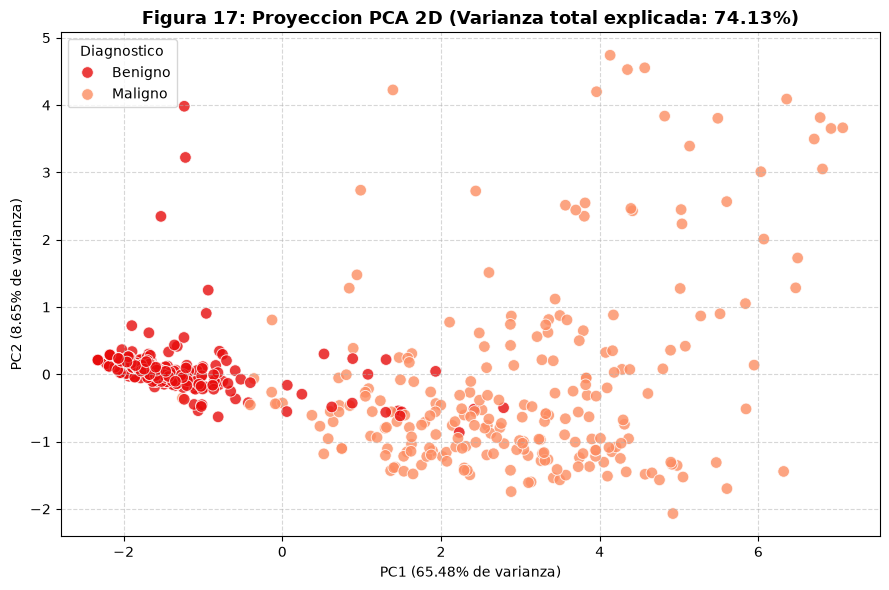

In [25]:
import numpy as np

from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler


X = df1.drop(columns=["id","class"])
Y = df1["class"].map({2: "Benigno", 4: "Maligno"})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns = ["Componente Principal 1 (PC1)", "Componente Principal 2 (PC2)"])
df_pca["Diagnostico"] = Y.values

varianza_explicada = pca.explained_variance_ratio_ * 100
varianza_acumulada = np.sum(varianza_explicada)

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df_pca,
    x="Componente Principal 1 (PC1)",
    y="Componente Principal 2 (PC2)",
    hue="Diagnostico",
    palette={
        "Benigno": "#e70c0c",
        "Maligno": "#fc8d62",
    },
    alpha=0.8,
    s=70
)

plt.title(f"Figura 17: Proyeccion PCA 2D (Varianza total explicada: {varianza_acumulada:.2f}%)", fontsize=13, fontweight="bold")
plt.xlabel(f"PC1 ({varianza_explicada[0]:.2f}% de varianza)")
plt.ylabel(f"PC2 ({varianza_explicada[1]:.2f}% de varianza)")
plt.legend(title="Diagnostico", loc="best")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("Images/Figura 17 - Proyeccion de PCA.png", dpi=300, bbox_inches="tight")
plt.show()



Como se puede observar en la Figura 17, resultado del PCA, las celulas benignas tienen un comportamiento similar y se agrupan de lado izquierdo casi compactadas salvo por valores que estan dispersos, en cuando a los valores para celulas malignas estan agrupadas de lado derecho pero mucho mas separadas que las celular benignas. Con esto podemos contrastar que el cancer no sigue una regla estandarizada de caracteristicas, las celulas se deforman y cambian de forma con alta variabilidad.

---

## Referencias

Elston, C. W., & Ellis, I. O. (1991). Pathological prognostic factors in breast cancer. I. The value of histological grade in breast cancer: Experience from a large study with long-term follow-up. Histopathology, 19(5), 403–410. https://doi.org/10.1111/j.1365-2559.1991.tb00229.x

Mendoza, P., Lacambra, M., Tan, P. H., & Tse, G. M. (2011). Fine needle aspiration cytology of the breast: The nonmalignant categories. Pathology Research International, 2011, 547580. https://doi.org/10.4061/2011/547580

Orsolic, I., Jurada, D., Pullen, N., Oren, M., Eliopoulos, A. G., & Volarevic, S. (2016). The relationship between the nucleolus and cancer: current evidence and emerging paradigms. Seminars in Cancer Biology, 37–38, 36–50. https://doi.org/10.1016/j.semcancer.2015.12.001

Robinson, I. A., McKee, G., Nicholson, A., D'Arcy, J., Jackson, P. A., Cook, M. G., & Kissin, M. W. (1994). Prognostic value of cytological grading of fine-needle aspirates from breast carcinomas. The Lancet, 343(8903), 947–949. https://doi.org/10.1016/S0140-6736(94)90066-3

Sehgal, P., & Chaturvedi, P. (2023). Chromatin and cancer: Implications of disrupted chromatin organization in tumorigenesis and its diversification. Cancers, 15(2), 466. https://doi.org/10.3390/cancers15020466

Virtual Pathology at Leeds. (s. f.). Normal and benign cells (Breast) [Slide Seminar]. University of Leeds. https://elearning.virtualpathology.leeds.ac.uk/slide_seminar.php?seminar=0&subject=Cytology&topic=Normal%20and%20benign%20cells%20(Breast)&return=Breast

Wolberg, W. H., & Mangasarian, O. L. (1990). Multisurface method of pattern separation for medical diagnosis applied to breast cytology. Proceedings of the National Academy of Sciences, 87(23), 9193–9196. https://doi.org/10.1073/pnas.87.23.9193


## Extras y Declaracion de uso de IA

Se utilizo un modelo de inteligencia artificial (Google Gemini, Flash 3.6) como asistente en la revision, edicion y optimizacion del formato Markdown de este Notebook.

* Prompt Utilizado:
``
"Revisa este texto en markdow, corrige ortografia y sintaxis. Mejora la fluidez sin cambiar la idea principal ni la estructura de mi escritura"
``